In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("../02_Cleaned_Data/Ecommerce_Cleaned_Sales_Data.csv")

df.head()

,Order_ID,Order_Date,Customer_Name,Product,Category,Region,Quantity,Unit_Price,Discount,Sales
0,1001,2026-01-05,Aarav Shah,Laptop,Electronics,North,2,55000,0.05,104500.0
1,1002,2026-01-12,Priya Mehta,Smartphone,Electronics,West,3,28000,0.03,81480.0
2,1003,2026-01-18,Rohan Patil,Office Chair,Furniture,South,2,12000,0.10,21600.0
3,1004,2026-01-25,Sneha Joshi,Desk,Furniture,East,1,18000,0.05,17100.0
4,1005,2026-02-03,Vikram Singh,Laptop,Electronics,West,1,55000,0.02,53900.0


In [3]:
print("Number of Rows:", df.shape[0])
print("Number of Columns:", df.shape[1])

print("\nColumn Names:")
print(df.columns.tolist())

Number of Rows: 36
Number of Columns: 10

Column Names:
['Order_ID', 'Order_Date', 'Customer_Name', 'Product', 'Category', 'Region', 'Quantity', 'Unit_Price', 'Discount', 'Sales']


In [4]:
print("Missing Values:")
print(df.isnull().sum())

Missing Values:
Order_ID         0
Order_Date       0
Customer_Name    0
Product          0
Category         0
Region           0
Quantity         0
Unit_Price       0
Discount         0
Sales            0
dtype: int64


In [5]:
print("Duplicate Rows:", df.duplicated().sum())

Duplicate Rows: 0


In [6]:
total_sales = df["Sales"].sum()
total_orders = df["Order_ID"].nunique()
total_customers = df["Customer_Name"].nunique()
total_quantity = df["Quantity"].sum()
average_order_value = total_sales / total_orders

print("Total Sales:", total_sales)
print("Total Orders:", total_orders)
print("Total Customers:", total_customers)
print("Total Quantity:", total_quantity)
print("Average Order Value:", average_order_value)

Total Sales: 2140770.0
Total Orders: 36
Total Customers: 36
Total Quantity: 90
Average Order Value: 59465.833333333336


In [7]:
category_sales = df.groupby("Category")["Sales"].sum().sort_values(ascending=False)

print(category_sales)

Category
Electronics    1641450.0
Furniture       499320.0
Name: Sales, dtype: float64


In [8]:
region_sales = df.groupby("Region")["Sales"].sum().sort_values(ascending=False)

print(region_sales)

Region
North    726880.0
West     600240.0
East     469620.0
South    344030.0
Name: Sales, dtype: float64


In [9]:
df["Order_Date"] = pd.to_datetime(df["Order_Date"])

monthly_sales = (
    df.groupby(df["Order_Date"].dt.to_period("M"))["Sales"]
    .sum()
)

print(monthly_sales)

Order_Date
2026-01    224680.0
2026-02    224380.0
2026-03    293600.0
2026-04    288960.0
2026-05    221350.0
2026-06    254180.0
2026-07    178820.0
2026-08    189000.0
2026-09    265800.0
Freq: M, Name: Sales, dtype: float64


In [10]:
top_products = (
    df.groupby("Product")["Sales"]
    .sum()
    .sort_values(ascending=False)
    .head(5)
)

print(top_products)

Product
Laptop          733150.0
Smartphone      509880.0
Tablet          398420.0
Office Chair    279360.0
Desk            219960.0
Name: Sales, dtype: float64


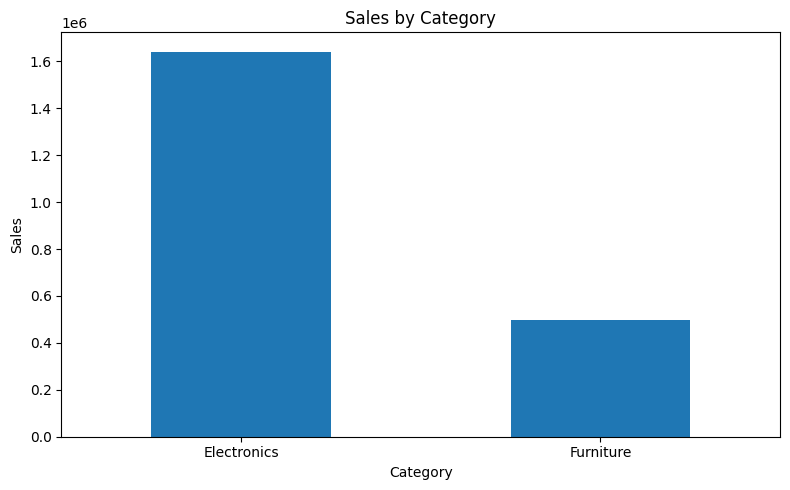

In [11]:
category_sales.plot(kind="bar", figsize=(8, 5))

plt.title("Sales by Category")
plt.xlabel("Category")
plt.ylabel("Sales")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

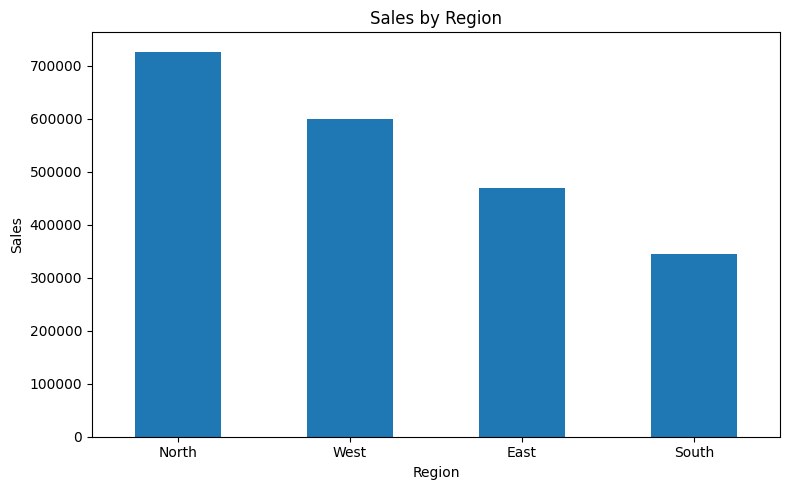

In [12]:
region_sales.plot(kind="bar", figsize=(8, 5))

plt.title("Sales by Region")
plt.xlabel("Region")
plt.ylabel("Sales")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

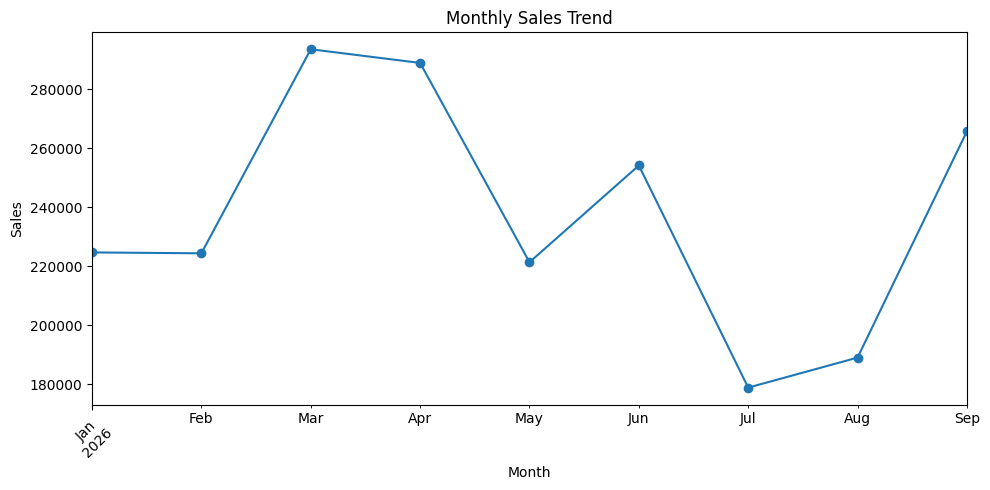

In [13]:
monthly_sales.plot(kind="line", marker="o", figsize=(10, 5))

plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Sales")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

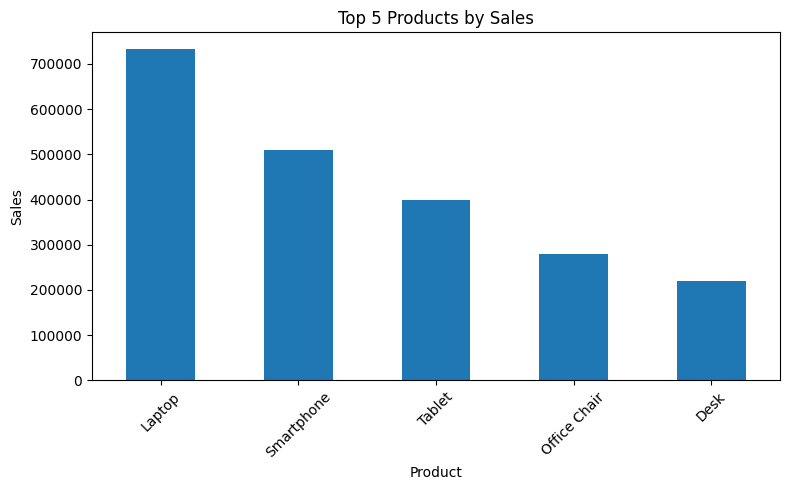

In [14]:
top_products.plot(kind="bar", figsize=(8, 5))

plt.title("Top 5 Products by Sales")
plt.xlabel("Product")
plt.ylabel("Sales")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [15]:
highest_category = category_sales.idxmax()
highest_category_sales = category_sales.max()

highest_region = region_sales.idxmax()
highest_region_sales = region_sales.max()

highest_product = top_products.idxmax()
highest_product_sales = top_products.max()

highest_month = monthly_sales.idxmax()
highest_month_sales = monthly_sales.max()

lowest_month = monthly_sales.idxmin()
lowest_month_sales = monthly_sales.min()

print("Highest Sales Category:", highest_category)
print("Highest Category Sales:", highest_category_sales)

print("\nBest Performing Region:", highest_region)
print("Region Sales:", highest_region_sales)

print("\nTop Product:", highest_product)
print("Product Sales:", highest_product_sales)

print("\nHighest Sales Month:", highest_month)
print("Highest Monthly Sales:", highest_month_sales)

print("\nLowest Sales Month:", lowest_month)
print("Lowest Monthly Sales:", lowest_month_sales)

Highest Sales Category: Electronics
Highest Category Sales: 1641450.0

Best Performing Region: North
Region Sales: 726880.0

Top Product: Laptop
Product Sales: 733150.0

Highest Sales Month: 2026-03
Highest Monthly Sales: 293600.0

Lowest Sales Month: 2026-07
Lowest Monthly Sales: 178820.0
